### Análisis de incosistencias/patrones en los datos procesados

FALTA POR HACER:
- Diferencia entre llegada_punto y salida_punto (en distancia y en tiempo?)
- Gráficos de tráfico por horas
- Buscar dias - outliers
- Buscar patrones - cada semana/dia por tipo de avion...

In [69]:
import pandas as pd
import plotly.express as px


In [70]:
df_original = pd.read_csv("../../data/Train/train.csv", sep=";")
df_original.head()

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
0,347259,2025-01-01 11:28:40.463,2025-01-01 11:29:06.856,2025-01-01 11:30:18.069,97.606,Heavy (larger than 136000 kg),-3.572662,40.491829,-3.573822,40.491829,Z3,False,18R/36L,2025-01-01,11
1,abfdd1,2025-01-01 12:53:57.851,2025-01-01 12:54:15.692,2025-01-01 12:55:08.113,70.262,Heavy (larger than 136000 kg),-3.572788,40.491846,-3.573818,40.491858,Z3,False,18R/36L,2025-01-01,12
2,4cacdf,2025-01-01 10:20:25.104,2025-01-01 10:20:38.071,2025-01-01 10:21:24.027,58.923,Medium 2 (between 34000 kg to 136000 kg),-3.561172,40.501179,-3.560085,40.501343,Y3,False,18L/36R,2025-01-01,10
3,34754c,2025-01-01 05:37:49.944,2025-01-01 05:38:03.062,2025-01-01 05:38:52.151,62.207,Medium 2 (between 34000 kg to 136000 kg),-3.576462,40.492481,-3.575488,40.492766,Z4,False,18R/36L,2025-01-01,5
4,34754c,2025-01-01 12:45:58.757,2025-01-01 12:46:16.737,2025-01-01 12:48:41.019,162.262,Medium 2 (between 34000 kg to 136000 kg),-3.576612,40.492475,-3.575519,40.492777,Z4,False,18R/36L,2025-01-01,12


### Filtrar por parado = True

In [71]:
#df_original = df_original[df_original.parado]

In [72]:
#mask = (df_original['despegue'] >= '2024-12-01') & (df_original['despegue'] <= '2024-12-08')
#df_original = df_original[mask]

In [73]:
df_original.columns

Index(['ICAO', 'llegada_punto', 'salida_punto', 'despegue', 'tiempo_espera',
       'aircraft_type', 'llegada_lon', 'llegada_lat', 'salida_lon',
       'salida_lat', 'holding_point', 'parado', 'runway', 'fecha_despegue',
       'hora_despegue'],
      dtype='object')

In [74]:
print('Entre que fechas son los despegues')
print(df_original.despegue.min(), " -- ", df_original.despegue.max())

Entre que fechas son los despegues
2024-11-07 00:05:24.006  --  2025-01-17 23:56:59.190


In [75]:
counts = df_original.parado.value_counts().reset_index()
counts.columns = ['parado', 'count']
fig = px.bar(counts, x='parado', y='count', text='count',width=500, height=500)
fig.show()

In [76]:
px.histogram(df_original, 'tiempo_espera', title='Distribución segundos de espera')

In [77]:
px.histogram(df_original[df_original.tiempo_espera < 20 * 60], 'tiempo_espera', title='Distribución segundos de espera (menores a 20 mins)')

In [78]:
px.histogram(df_original[df_original.tiempo_espera < 10 * 60], 'tiempo_espera', title='Distribución segundos de espera (menores a 10 mins)')

Nos quedamos con los últimos datos

In [79]:
df = df_original.copy()
df = df[df.tiempo_espera < 10 * 60]
print(df_original.shape[0], "->", df.shape[0])

36673 -> 35837


### Analisis de NA's

In [80]:
df.isna().sum()

ICAO                0
llegada_punto       0
salida_punto       36
despegue            0
tiempo_espera       0
aircraft_type     145
llegada_lon         0
llegada_lat         0
salida_lon         36
salida_lat         36
holding_point       0
parado              0
runway             15
fecha_despegue      0
hora_despegue       0
dtype: int64

In [81]:
df[df['aircraft_type'].isna()].head(3)

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
162,34604c,2025-01-01 14:54:45.587,2025-01-01 14:54:46.412,2025-01-01 14:54:46.412,0.825,NaN,-3.560928,40.499405,-3.560928,40.499405,Y1,False,18L/36R,2025-01-01,14
163,34604c,2025-01-01 14:54:49.104,2025-01-01 14:54:54.894,2025-01-01 14:55:49.321,60.217,NaN,-3.560593,40.499428,-3.560028,40.499599,Y1,False,18L/36R,2025-01-01,14
312,3944f9,2025-01-01 09:09:53.047,2025-01-01 09:10:09.469,2025-01-01 09:12:10.207,137.160,NaN,-3.561203,40.499428,-3.560043,40.499599,Y1,False,18L/36R,2025-01-01,9


#### 2 despegues en menos de 5 minutos

In [82]:
df[df['ICAO'] == '34530e'].iloc[9:11]

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
5901,34530e,2025-01-11 09:20:09.844,2025-01-11 09:20:20.250,2025-01-11 09:21:10.072,60.228,Medium 2 (between 34000 kg to 136000 kg),-3.561203,40.501167,-3.560085,40.501343,Y3,False,18L/36R,2025-01-11,9
7019,34530e,2025-01-13 07:01:49.239,2025-01-13 07:03:00.776,2025-01-13 07:04:20.930,151.691,Medium 2 (between 34000 kg to 136000 kg),-3.561234,40.499416,-3.560101,40.499597,Y1,False,18L/36R,2025-01-13,7


In [83]:
df[df['runway'].isna()]

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
436,4d23fa,2025-01-01 14:01:32.045,2025-01-01 14:01:45.773,2025-01-01 14:02:41.972,69.927,Medium 2 (between 34000 kg to 136000 kg),-3.561218,40.501167,-3.560054,40.501331,Y3,False,NaN,2025-01-01,14
7142,34750f,2025-01-13 13:57:54.977,2025-01-13 13:57:56.299,2025-01-13 13:57:56.299,1.322,Medium 2 (between 34000 kg to 136000 kg),-3.576268,40.491567,-3.576268,40.491625,Z2,False,NaN,2025-01-13,13
8520,3451d8,2025-01-16 10:37:03.685,2025-01-16 10:39:18.405,2025-01-16 10:39:47.611,163.926,Medium 2 (between 34000 kg to 136000 kg),-3.572632,40.491835,-3.573792,40.491829,Z3,False,NaN,2025-01-16,10
8706,347311,2025-01-16 06:04:16.447,2025-01-16 06:04:29.541,2025-01-16 06:05:08.383,51.936,Medium 2 (between 34000 kg to 136000 kg),-3.561234,40.499428,-3.560089,40.499599,Y1,False,NaN,2025-01-16,6
10969,3cd906,2024-11-09 16:31:39.385,2024-11-09 16:31:48.612,2024-11-09 16:31:48.612,9.227,Medium 1 (between 7000 kg and 34000 kg),-3.576462,40.491737,-3.576175,40.491788,Z2,False,NaN,2024-11-09,16
10970,3cd906,2024-11-09 16:31:48.612,2024-11-09 16:31:48.650,2024-11-09 16:31:48.650,0.038,NaN,-3.576141,40.491795,-3.576141,40.491795,Z2,False,NaN,2024-11-09,16
21985,34444b,2024-12-01 08:30:54.936,2024-12-01 08:31:11.578,2024-12-01 08:33:12.261,137.325,Medium 2 (between 34000 kg to 136000 kg),-3.537879,40.472422,-3.537098,40.471643,KA6,False,NaN,2024-12-01,8
24845,34530e,2024-12-06 10:37:17.504,2024-12-06 10:37:37.380,2024-12-06 10:37:37.380,19.876,Medium 2 (between 34000 kg to 136000 kg),-3.572861,40.491840,-3.573471,40.491829,Z3,True,NaN,2024-12-06,10
30360,3452c8,2024-12-15 07:04:08.506,2024-12-15 07:07:59.705,2024-12-15 07:07:59.705,231.199,Medium 2 (between 34000 kg to 136000 kg),-3.576159,40.491683,-3.575790,40.491898,Z2,True,NaN,2024-12-15,7
30361,3452c8,2024-12-15 07:08:02.071,2024-12-15 07:08:10.592,2024-12-15 07:08:13.799,11.728,NaN,-3.575668,40.491955,-3.575254,40.492114,Z2,False,NaN,2024-12-15,7


In [84]:
df[df['salida_punto'].isna()].head(2)

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
2454,347588,2025-01-05 16:53:06.292,NaN,2025-01-05 16:55:26.283,139.991,Medium 2 (between 34000 kg to 136000 kg),-3.574722,40.486828,NaN,NaN,LD,False,14R/32L,2025-01-05,16
2470,345686,2025-01-05 15:58:17.141,NaN,2025-01-05 16:03:38.818,321.677,Medium 2 (between 34000 kg to 136000 kg),-3.574864,40.486900,NaN,NaN,LD,True,14R/32L,2025-01-05,16


Hay un segundo punto, despues del punto que no tiene salida

In [85]:
df[df['ICAO'] == '344417'].iloc[3:5]

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
1700,344417,2025-01-03 15:51:27.422,2025-01-03 15:51:39.039,2025-01-03 15:52:26.585,59.163,Medium 2 (between 34000 kg to 136000 kg),-3.561203,40.499485,-3.560089,40.499622,Y1,False,18L/36R,2025-01-03,15
2247,344417,2025-01-04 06:35:29.344,2025-01-04 06:37:25.583,2025-01-04 06:38:18.229,168.885,Medium 2 (between 34000 kg to 136000 kg),-3.576599,40.492481,-3.575394,40.492777,Z4,True,18R/36L,2025-01-04,6


### Eliminamos filas con algún NA

In [86]:
df = df.dropna()

Vamos a ver el numero de despegues por avion

In [87]:
icao_counts = df.drop_duplicates(subset=['ICAO', 'despegue']) # para no contar el mismo despegue 2 veces si pasa por 2 puntos
icao_counts = icao_counts.groupby(["ICAO", "aircraft_type"])["despegue"].count()
print("MAX", icao_counts.max())
print("MEDIA", icao_counts.mean())
print("MEDIANA", icao_counts.median())
fig = px.histogram(icao_counts.reset_index(), 'despegue', title='Distribución numero de despegues por avion', labels={'despegue': 'total numero de despegue'})
fig.show()

MAX 212
MEDIA 9.7818431911967
MEDIANA 3.0


In [88]:
fig = px.histogram(icao_counts.reset_index(), 'despegue', color="aircraft_type", title='Distribución numero de despegues por avion', labels={'despegue': 'total numero de despegue'})
fig.show()

In [89]:
hp_count = df.groupby(["ICAO", "despegue"])["holding_point"].count().sort_values(ascending=False)

In [90]:
hp_count[hp_count > 1]

ICAO    despegue               
4ca804  2024-11-10 19:52:09.919    5
344446  2024-11-28 15:05:45.010    4
4d226e  2024-11-09 18:25:09.328    4
4ca892  2024-11-07 18:36:53.970    4
34558e  2024-11-28 14:55:26.474    4
                                  ..
344216  2025-01-09 14:13:22.844    2
        2024-11-21 15:51:25.470    2
e06589  2024-11-09 18:29:47.934    2
34304f  2024-11-27 14:17:58.515    2
040188  2024-11-07 18:38:10.154    2
Name: holding_point, Length: 61, dtype: int64

In [91]:
df[df.ICAO == '4ca804'].sort_values(by=['despegue', 'llegada_punto']).iloc[8:]

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
11527,4ca804,2024-11-10 05:43:13.732,2024-11-10 05:43:31.476,2024-11-10 05:45:02.194,108.462,Medium 2 (between 34000 kg to 136000 kg),-3.576612,40.492498,-3.575500,40.492779,Z4,False,18R/36L,2024-11-10,5
11528,4ca804,2024-11-10 13:51:11.120,2024-11-10 13:51:28.310,2024-11-10 13:55:17.823,246.703,Medium 2 (between 34000 kg to 136000 kg),-3.561234,40.499348,-3.560101,40.499621,Y1,False,18L/36R,2024-11-10,13
11529,4ca804,2024-11-10 19:42:38.926,2024-11-10 19:42:44.180,2024-11-10 19:52:09.919,570.993,Medium 2 (between 34000 kg to 136000 kg),-3.572815,40.479343,-3.573257,40.479790,LF,False,14L/32R,2024-11-10,19
11530,4ca804,2024-11-10 19:43:34.278,2024-11-10 19:43:36.427,2024-11-10 19:52:09.919,515.641,Medium 2 (between 34000 kg to 136000 kg),-3.577057,40.483578,-3.577205,40.483723,L1,False,14L/32R,2024-11-10,19
11531,4ca804,2024-11-10 19:43:38.482,2024-11-10 19:43:44.358,2024-11-10 19:52:09.919,511.437,Medium 2 (between 34000 kg to 136000 kg),-3.577361,40.483874,-3.577766,40.484305,LA,False,14L/32R,2024-11-10,19
11532,4ca804,2024-11-10 19:43:48.460,2024-11-10 19:43:50.407,2024-11-10 19:52:09.919,501.459,Medium 2 (between 34000 kg to 136000 kg),-3.578016,40.484608,-3.578141,40.484759,LB,False,14L/32R,2024-11-10,19
11533,4ca804,2024-11-10 19:49:46.650,2024-11-10 19:50:53.796,2024-11-10 19:52:09.919,143.269,Medium 2 (between 34000 kg to 136000 kg),-3.559898,40.494511,-3.559024,40.495000,K2,True,14L/32R,2024-11-10,19
12135,4ca804,2024-11-11 05:46:16.745,2024-11-11 05:49:18.743,2024-11-11 05:50:20.691,243.946,Medium 2 (between 34000 kg to 136000 kg),-3.576447,40.491726,-3.575316,40.492091,Z2,True,18R/36L,2024-11-11,5
12136,4ca804,2024-11-11 12:53:33.280,2024-11-11 12:53:43.663,2024-11-11 12:54:21.622,48.342,Medium 2 (between 34000 kg to 136000 kg),-3.561240,40.499493,-3.560104,40.499645,Y1,False,18L/36R,2024-11-11,12
12137,4ca804,2024-11-11 20:19:33.551,2024-11-11 20:20:27.031,2024-11-11 20:21:27.213,113.662,Medium 2 (between 34000 kg to 136000 kg),-3.559784,40.494335,-3.558837,40.494907,K2,False,14L/32R,2024-11-11,20


#### Solo hay 2 casos donde los aviones pasan por mas de 1 punto de espera al despegar

In [92]:
import geopandas as gpd

gdf = gpd.read_file('../../data/geojson/holding_points.geojson')
taxiways = gpd.read_file("../../data/geojson/taxiways.geojson")
runways = gpd.read_file("../../data/geojson/runways.geojson")
gdf.head(1)

,OBJECTID,LASTMOD_DATE,LAT_TXT,LONG_TXT,GFID,LATLONG_RESOLUTION,LATLONG_ACCURACY,LASTMOD_AMDT,DESIGNATOR,STOPBAR,PARENT_ADHP,REMARKS_TXT,geometry
0,1190,1689239365000,"402926,3514N","0033423,1352W",87F4653B-2759-449F-8558-223A85EE69EA,None,None,AIRAC - 10/23,Z1,1.0,C46939D7-07D9-4BA7-9D4C-AF3E1B30DCD0,Con iluminación LED. // LED ligthing.,POINT (-3.57309 40.49065)


/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_39791/2696595465.py:13: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_39791/2696595465.py:16: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_39791/2696595465.py:31: UserWarning:

Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler



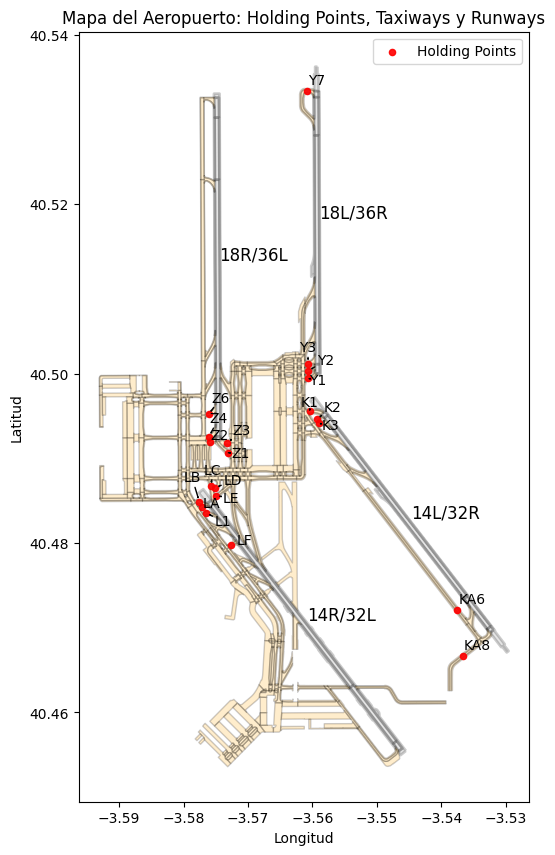

In [93]:
import matplotlib.pyplot as plt

from adjustText import adjust_text # basicamente ayuda a que el texto no solape

fig, ax = plt.subplots(figsize=(10, 10))

texts = []
for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf['DESIGNATOR']):
    texts.append(ax.text(x, y, label, fontsize=10, ha='left', va='bottom'))

# convertimos en una sola pieza (poligono)
runways_grouped = runways.dissolve(by='RWY', as_index=False)
runways_grouped['centroid'] = runways_grouped.geometry.centroid
runways_grouped.head()

for x, y, label in zip(runways_grouped.centroid.x, runways_grouped.centroid.y, runways_grouped['RWY']):
    texts.append(ax.text(x, y, label, fontsize=12, ha='left', va='bottom'))

# Plot layers
runways.plot(ax=ax, color="gray", edgecolor="black", alpha=0.2, linewidth=2, label="Runways")
taxiways.plot(ax=ax, color="orange", edgecolor="black", alpha=0.2, label="Taxiways")
gdf.plot(ax=ax, color="red", markersize=20, alpha=0.9, label="Holding Points")

# Adjust text to avoid overlaps
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black'))

# Añadir título y leyenda
plt.title("Mapa del Aeropuerto: Holding Points, Taxiways y Runways")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend()

# Mostrar el mapa
plt.show();

In [94]:
setAll = set(gdf.DESIGNATOR.unique())
setData = set(df.holding_point.unique())
diff = setAll.difference(setData)
if (bool(diff)):
    print("Puntos de espera que NO estan en los DATOS PROCESADOS:")
    print(diff)
else:
    print("TODOS LOS PUNTOS DE ESPERA ESTAN EN LOS DATOS")

Puntos de espera que NO estan en los DATOS PROCESADOS:
{'Y7', 'KA8'}


Vemos la distribución de las pistas

In [95]:
# para no contar 2 veces la misma pista cuando pasa por 2 puntos antes de despegar
counts = df.drop_duplicates(subset=['runway', 'despegue', 'ICAO'])['runway'].value_counts().reset_index()
counts.columns = ['runway', 'count']
fig = px.bar(counts, x='runway', y='count', text='count',width=500, height=500)
fig.show()

In [96]:
import plotly.express as px

value_counts = df['holding_point'].value_counts().reset_index()
value_counts.columns = ['holding_point', 'count']

fig = px.bar(value_counts, x='holding_point', y='count', title='Despegues por puntos de espera', text='count')

fig.update_layout(template='plotly_white')

fig.show()


/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_39791/3476943834.py:17: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_39791/3476943834.py:20: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_39791/3476943834.py:35: UserWarning:

Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler



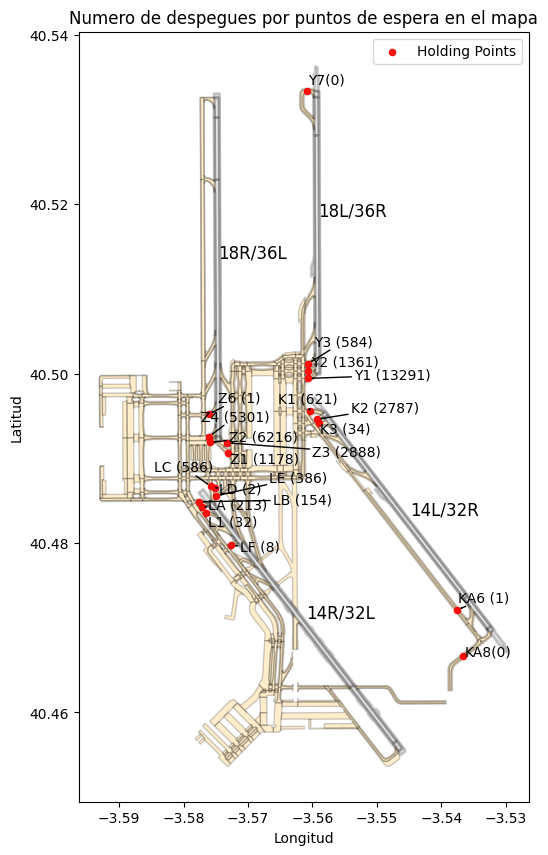

In [97]:
import matplotlib.pyplot as plt

from adjustText import adjust_text # basicamente ayuda a que el texto no solape

fig, ax = plt.subplots(figsize=(10, 10))

texts = []
value_counts = df['holding_point'].value_counts()
for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf['DESIGNATOR']):
    label_with_count = label + "(0)"
    if label in value_counts:
        label_with_count = f"{label} ({value_counts[label]})"
    texts.append(ax.text(x, y, label_with_count, fontsize=10, ha='left', va='bottom'))

# convertimos en una sola pieza (poligono)
runways_grouped = runways.dissolve(by='RWY', as_index=False)
runways_grouped['centroid'] = runways_grouped.geometry.centroid
runways_grouped.head()

for x, y, label in zip(runways_grouped.centroid.x, runways_grouped.centroid.y, runways_grouped['RWY']):
    texts.append(ax.text(x, y, label, fontsize=12, ha='left', va='bottom'))

# Plot layers
runways.plot(ax=ax, color="gray", edgecolor="black", alpha=0.2, linewidth=2, label="Runways")
taxiways.plot(ax=ax, color="orange", edgecolor="black", alpha=0.2, label="Taxiways")
gdf.plot(ax=ax, color="red", markersize=20, alpha=0.9, label="Holding Points")

# Adjust text to avoid overlaps
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black'))

# Añadir título y leyenda
plt.title("Numero de despegues por puntos de espera en el mapa")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend()

# Mostrar el mapa
plt.show();

Meter un color más rojo o más verde dependiendo de si tiene mas o menos despegues (se puede hacer una versión animada??)

In [ ]:
import pandas as pd
import geopandas as gpd
import folium
from folium.plugins import TimestampedGeoJson

counts_fecha = df[['despegue', 'holding_point']].copy()
counts_fecha['despegue'] = pd.to_datetime(counts_fecha['despegue']).dt.floor('H') # redondea a la hora (para eliminar minutos y segundos)

df_folium = counts_fecha.value_counts().reset_index()
df_folium = df_folium.merge(gdf[['DESIGNATOR', 'geometry']], left_on='holding_point', right_on='DESIGNATOR', how='left')
df_folium = df_folium.dropna(subset=['geometry'])  # Remove rows without geometry

# Convert to GeoDataFrame
gdf_anim = gpd.GeoDataFrame(df_folium, geometry='geometry')
gdf_anim.crs = gdf.crs  # inherit CRS

# STEP 2: Build GeoJSON format for Folium TimestampedGeoJson

# Folium expects a GeoJSON structure with timestamps
# We create a FeatureCollection with 'time' and 'iconstyle' properties

def gdf_to_timestamped_geojson(gdf):
    features = []
    for _, row in gdf.iterrows():
        feature = {
            'type': 'Feature',
            'geometry': row.geometry.__geo_interface__,
            'properties': {
                'time': row['despegue'].isoformat(),
                'popup': f"Holding Point: {row['holding_point']} count: {row['count']}",
                'icon': 'circle',
                'iconstyle': {
                    'fillColor': 'red',
                    'fillOpacity': 0.8,
                    'stroke': True,
                    'radius': 6
                }
            }
        }
        features.append(feature)

    return {
        'type': 'FeatureCollection',
        'features': features
    }

geojson_data = gdf_to_timestamped_geojson(gdf_anim)

# STEP 3: Create the Folium map

# Center of the map
map_center = [gdf.geometry.y.mean(), gdf.geometry.x.mean()]

m = folium.Map(location=map_center, zoom_start=12, tiles='cartodbpositron')

TimestampedGeoJson(
    data=geojson_data,
    transition_time=500,
    period='PT1H',  # ISO 8601 duration: 1 hour
    add_last_point=True,
    auto_play=True,
    loop=False,
    #max_speed=1,
    loop_button=True,
    date_options='YYYY-MM-DD HH:mm',
    time_slider_drag_update=True
).add_to(m)


m

In [60]:
# Extract latitude and longitude from geometry
gdf['lat'] = gdf.geometry.y
gdf['lon'] = gdf.geometry.x

# Value counts
value_counts = df['holding_point'].value_counts().reset_index()
value_counts.columns = ['holding_point', 'count']

# Merge counts into GeoDataFrame
gdf_merged = gdf.merge(value_counts, left_on='DESIGNATOR', right_on='holding_point', how='left')
gdf_merged['count'] = gdf_merged['count'].fillna(0)

# Plot the holding points on a map
fig = px.scatter_mapbox(
    gdf_merged,
    lat='lat',
    lon='lon',
    text='DESIGNATOR',
    size='count',
    size_max=20,
    zoom=11.4
)

fig.update_layout(
    mapbox_style="carto-positron",
    margin={"r": 0, "t": 0, "l": 0, "b": 0}
)

fig.show();

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_39791/2990192652.py:14: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [61]:
import pandas as pd
import plotly.express as px

counts_fecha = df[['despegue', 'runway']].copy()
counts_fecha['despegue'] = pd.to_datetime(counts_fecha['despegue']).dt.floor('H') # redondea a la hora (para eliminar minutos y segundos)

counts_fecha = counts_fecha.value_counts().reset_index()

# en este creamos una rejilla, para todas las fechas por horas y todos los runways
# para que en el grafico salga la línea en el 0 si no ha habido despegues a esa hora
all_hours = pd.date_range(start=counts_fecha['despegue'].min(), end=counts_fecha['despegue'].max(), freq='H')
all_runways = counts_fecha['runway'].unique()

full_index = pd.MultiIndex.from_product([all_hours, all_runways], names=['despegue', 'runway'])
counts_full = counts_fecha.set_index(['despegue', 'runway']).reindex(full_index, fill_value=0).reset_index()


fig = px.line(counts_full, x='despegue', y='count', color='runway',
              title='Despegues por horas y pista')
fig.show()

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_39791/713076718.py:5: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_39791/713076718.py:11: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [62]:
import pandas as pd
import plotly.express as px

counts_fecha = df[['despegue', 'runway']].copy()
counts_fecha['despegue'] = pd.to_datetime(counts_fecha['despegue']).dt.floor('H') # redondea a la hora (para eliminar minutos y segundos)

counts_fecha = counts_fecha.value_counts().reset_index()

# en este creamos una rejilla, para todas las fechas por horas y todos los runways
# para que en el grafico salga la línea en el 0 si no ha habido despegues a esa hora
all_hours = pd.date_range(start=counts_fecha['despegue'].min(), end=counts_fecha['despegue'].max(), freq='H')
all_runways = counts_fecha['runway'].unique()

full_index = pd.MultiIndex.from_product([all_hours, all_runways], names=['despegue', 'runway'])
counts_full = counts_fecha.set_index(['despegue', 'runway']).reindex(full_index, fill_value=0).reset_index()


fig = px.area(counts_full, x='despegue', y='count', color='runway',
              title='Despegues por horas y pista (APILADO)')
fig.show()

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_39791/4216646965.py:5: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_39791/4216646965.py:11: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [63]:
import pandas as pd
import plotly.express as px

counts_fecha = df[['despegue', 'holding_point']].copy()
counts_fecha['despegue'] = pd.to_datetime(counts_fecha['despegue']).dt.floor('H') # redondea a la hora (para eliminar minutos y segundos)

counts_fecha = counts_fecha.value_counts().reset_index()

# en este creamos una rejilla, para todas las fechas por horas y todos los runways
# para que en el grafico salga la línea en el 0 si no ha habido despegues a esa hora
all_hours = pd.date_range(start=counts_fecha['despegue'].min(), end=counts_fecha['despegue'].max(), freq='H')
all_runways = counts_fecha['holding_point'].unique()

full_index = pd.MultiIndex.from_product([all_hours, all_runways], names=['despegue', 'holding_point'])
counts_full = counts_fecha.set_index(['despegue', 'holding_point']).reindex(full_index, fill_value=0).reset_index()


fig = px.line(counts_full, x='despegue', y='count', color='holding_point',
              title='Despegues por horas y holding point')
fig.show()

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_39791/419709331.py:5: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_39791/419709331.py:11: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [64]:
import pandas as pd
import plotly.express as px

counts_fecha = df[['despegue', 'holding_point']].copy()
counts_fecha['despegue'] = pd.to_datetime(counts_fecha['despegue']).dt.floor('H') # redondea a la hora (para eliminar minutos y segundos)

counts_fecha = counts_fecha.value_counts().reset_index()

# en este creamos una rejilla, para todas las fechas por horas y todos los runways
# para que en el grafico salga la línea en el 0 si no ha habido despegues a esa hora
all_hours = pd.date_range(start=counts_fecha['despegue'].min(), end=counts_fecha['despegue'].max(), freq='H')
all_runways = counts_fecha['holding_point'].unique()

full_index = pd.MultiIndex.from_product([all_hours, all_runways], names=['despegue', 'holding_point'])
counts_full = counts_fecha.set_index(['despegue', 'holding_point']).reindex(full_index, fill_value=0).reset_index()


fig = px.area(counts_full, x='despegue', y='count', color='holding_point',
              title='Despegues por horas y holding point (APILADO)')
fig.show()

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_39791/143014589.py:5: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_39791/143014589.py:11: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [65]:
import pandas as pd
import plotly.express as px

counts_fecha = df[['despegue', 'aircraft_type']].copy()
counts_fecha['despegue'] = pd.to_datetime(counts_fecha['despegue']).dt.floor('H') # redondea a la hora (para eliminar minutos y segundos)

counts_fecha = counts_fecha.value_counts().reset_index()

# en este creamos una rejilla, para todas las fechas por horas y todos los runways
# para que en el grafico salga la línea en el 0 si no ha habido despegues a esa hora
all_hours = pd.date_range(start=counts_fecha['despegue'].min(), end=counts_fecha['despegue'].max(), freq='H')
all_runways = counts_fecha['aircraft_type'].unique()

full_index = pd.MultiIndex.from_product([all_hours, all_runways], names=['despegue', 'aircraft_type'])
counts_full = counts_fecha.set_index(['despegue', 'aircraft_type']).reindex(full_index, fill_value=0).reset_index()


fig = px.line(counts_full, x='despegue', y='count', color='aircraft_type',
              title='Despegues por horas y tipo de avion')
fig.show()

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_39791/2167324354.py:5: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_39791/2167324354.py:11: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [66]:
import pandas as pd
import plotly.express as px

counts_fecha = df[['despegue', 'aircraft_type']].copy()
counts_fecha['despegue'] = pd.to_datetime(counts_fecha['despegue']).dt.floor('H') # redondea a la hora (para eliminar minutos y segundos)

counts_fecha = counts_fecha.value_counts().reset_index()

# en este creamos una rejilla, para todas las fechas por horas y todos los runways
# para que en el grafico salga la línea en el 0 si no ha habido despegues a esa hora
all_hours = pd.date_range(start=counts_fecha['despegue'].min(), end=counts_fecha['despegue'].max(), freq='H')
all_runways = counts_fecha['aircraft_type'].unique()

full_index = pd.MultiIndex.from_product([all_hours, all_runways], names=['despegue', 'aircraft_type'])
counts_full = counts_fecha.set_index(['despegue', 'aircraft_type']).reindex(full_index, fill_value=0).reset_index()


fig = px.area(counts_full, x='despegue', y='count', color='aircraft_type',
              title='Despegues por horas y tipo de avion (APILADO)')
fig.show()

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_39791/798781643.py:5: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_39791/798781643.py:11: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [67]:
pivot_df = df.pivot_table(index='holding_point', columns='runway', values='despegue', aggfunc='count').T

fig = px.imshow(pivot_df, title='Despegues por pista y punto de espera')
fig.show()


In [68]:
pivot_df = df.pivot_table(index='holding_point', columns='aircraft_type', values='despegue', aggfunc='count').T

fig = px.imshow(pivot_df, title='Puntos de espera por los que pasan diferentes tipos de aviones')
fig.show()